# Warwick SE-NAV — Simulated Urban Multipath Deep-Dive

This notebook mirrors the SDC-2023 `routen` deep-dive, but on a **physics-based ray-tracing simulation** produced by **SE-NAV** (OKTAL-SE). A vehicle (a VW *Golf 4*) is driven through a 3-D city model and every GNSS ray is traced, so we have **exact line-of-sight / non-line-of-sight ground truth** — far cleaner than a device's own `MultipathIndicator` flag.

**Scenario:** ~2,842 epochs of a drive at **~52.38 deg N, 1.56 deg W (Coventry / University of Warwick, UK)**.

**Label — `Visibility`:** `2 = DIRECT` (line-of-sight, clean), `1 = INDIRECT` (the direct path is blocked, signal arrives only via reflection = **NLOS multipath**), `0 = not visible`. We classify, among *visible* satellites, **NLOS (multipath = 1) vs LOS (0)**.

The flow is the same five acts: **map -> parse -> EDA -> classify -> compare on the map**.

## 0. Setup & SE-NAV parser

SE-NAV writes MATLAB-style `.m` text files: a `//DATA` header, then assignments like `VAR(i, j:k, t) = [ ... ];` where `t` is the epoch. The helper below extracts those blocks; angles are stored in **radians**.

In [1]:
try:
    import folium; from folium.plugins import HeatMap
except ImportError:
    import sys, subprocess; subprocess.check_call([sys.executable,'-m','pip','install','folium'])
    import folium; from folium.plugins import HeatMap

import os, re, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../..'))
WARWICK  = os.path.join(BASE_DIR, 'data/01_raw/Warwick')
print('Data dir:', WARWICK, '| exists:', os.path.isdir(WARWICK))

_BLK = re.compile(r'(\w+)\(([^)]*)\)\s*=\s*\[(.*?)\]\s*;', re.S)
def read_blocks(fn):
    with open(os.path.join(WARWICK, fn), 'r', errors='ignore') as fh:
        txt = fh.read()
    txt = '\n'.join(l for l in txt.splitlines() if not l.startswith('//'))
    return _BLK.findall(txt)   # list of (name, index_string, body)
def epoch_of(idx):
    return int(idx.split(',')[-1])
print('Parser ready.')

Data dir: c:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/01_raw/Warwick | exists: True
Parser ready.


## 1. Map the Route & Where Multipath Occurs

A light first pass: the vehicle trajectory (`vehicule_Golf4.m`, lat/lon in radians) and, per epoch, how many visible satellites are NLOS (`Visibility.m`). The **NLOS fraction** `n_nlos / n_visible` is the per-location multipath intensity.

In [2]:
# vehicle trajectory: cols = ECEF xyz, TopoEast xyz, lat(rad), lon(rad), height
veh = {}
for _, idx, body in read_blocks('vehicule_Golf4.m'):
    v = [float(x) for x in body.split()]
    veh[epoch_of(idx)] = (np.degrees(v[6]), ((np.degrees(v[7]) + 180) % 360) - 180)
veh_df = pd.DataFrame([(k, a, b) for k, (a, b) in veh.items()],
                      columns=['epoch', 'lat', 'lon']).sort_values('epoch').reset_index(drop=True)

# visibility -> per-epoch NLOS fraction
visi = {epoch_of(i): [int(x) for x in b.split()] for _, i, b in read_blocks('Visibility.m')}
rows = []
for t, arr in visi.items():
    a = np.array(arr)
    n_vis = int((a != 0).sum()); n_nlos = int((a == 1).sum())
    rows.append((t, n_vis, n_nlos, n_nlos / n_vis if n_vis else 0.0))
ep = pd.DataFrame(rows, columns=['epoch', 'n_vis', 'n_nlos', 'nlos_frac'])
epoch_map = veh_df.merge(ep, on='epoch').dropna(subset=['lat', 'lon'])
print(f'{len(epoch_map):,} epochs mapped   route bbox: lat '
      f"{epoch_map.lat.min():.4f}..{epoch_map.lat.max():.4f}  lon {epoch_map.lon.min():.4f}..{epoch_map.lon.max():.4f}")
print(f"Epochs with >=1 NLOS satellite: {(epoch_map.n_nlos>0).sum():,} ({100*(epoch_map.n_nlos>0).mean():.1f}%)")
epoch_map.head()

2,842 epochs mapped   route bbox: lat 52.3791..52.3847  lon -1.5649..-1.5574
Epochs with >=1 NLOS satellite: 2,516 (88.5%)


,epoch,lat,lon,n_vis,n_nlos,nlos_frac
0,1,52.384614,-1.558807,9,1,0.111111
1,2,52.384614,-1.558807,9,1,0.111111
2,3,52.384614,-1.558807,9,1,0.111111
3,4,52.384614,-1.558807,9,2,0.222222
4,5,52.384614,-1.558749,9,2,0.222222


### 1a. Interactive map — NLOS intensity along the route

Colour scale: **green = low** NLOS fraction, **yellow = medium**, **red = high**. The fraction is normalised to its observed range so the full green->red spread is used.

In [3]:
cmap = plt.cm.RdYlGn_r
MP_VMAX = float(epoch_map['nlos_frac'].quantile(0.95)) or float(epoch_map['nlos_frac'].max())
mp_norm = mcolors.Normalize(vmin=0.0, vmax=MP_VMAX, clip=True)
def frac_to_hex(f):
    return mcolors.to_hex(cmap(mp_norm(f)))
print(f'Colour scale: green=0  ->  red>={MP_VMAX:.2f} NLOS fraction')

center = [epoch_map.lat.mean(), epoch_map.lon.mean()]
m = folium.Map(location=center, zoom_start=16, tiles='cartodbpositron')
folium.TileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                 attr='Esri', name='Esri Satellite', control=True).add_to(m)
route = list(zip(epoch_map.lat, epoch_map.lon))
folium.PolyLine(route, color='gray', weight=2, opacity=0.6).add_to(m)
for _, r in epoch_map.iterrows():
    folium.CircleMarker([r.lat, r.lon], radius=3 + 6 * r.nlos_frac,
        color=frac_to_hex(r.nlos_frac), fill=True, fill_color=frac_to_hex(r.nlos_frac),
        fill_opacity=0.75, weight=0,
        tooltip=f'{int(r.n_nlos)}/{int(r.n_vis)} sats NLOS ({r.nlos_frac*100:.0f}%)').add_to(m)
folium.Marker(route[0], popup='Start', icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker(route[-1], popup='End', icon=folium.Icon(color='black', icon='stop')).add_to(m)
legend = f'''<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
  padding:8px 12px;border:1px solid #999;border-radius:5px;font-size:12px;font-family:sans-serif;">
  <b>NLOS intensity</b><br><div style="height:12px;width:160px;margin:4px 0;background:linear-gradient(
  to right,{frac_to_hex(0)},{frac_to_hex(MP_VMAX/2)},{frac_to_hex(MP_VMAX)});"></div>
  <span style="float:left;">0%</span><span style="float:right;">&ge;{MP_VMAX*100:.0f}% of sats</span></div>'''
m.get_root().html.add_child(folium.Element(legend))
folium.LayerControl().add_to(m)
display(m)

Colour scale: green=0  ->  red>=0.56 NLOS fraction


### 1b. Heat map & static scatter

In [4]:
hm = folium.Map(location=center, zoom_start=16, tiles='cartodbpositron')
HeatMap(epoch_map[['lat','lon','n_nlos']].values.tolist(), radius=12, blur=9, min_opacity=0.3).add_to(hm)
folium.PolyLine(route, color='black', weight=1, opacity=0.4).add_to(hm)
display(hm)

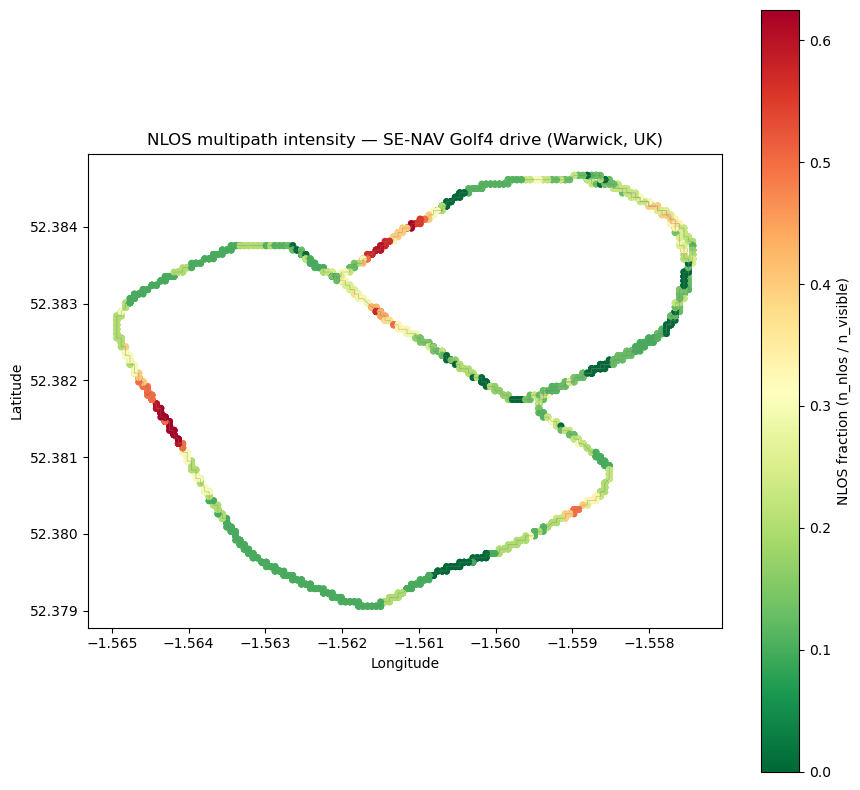

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(epoch_map.lon, epoch_map.lat, c=epoch_map.nlos_frac, cmap='RdYlGn_r',
                s=16, vmin=0, vmax=epoch_map.nlos_frac.quantile(0.98))
ax.plot(epoch_map.lon, epoch_map.lat, color='gray', lw=0.5, alpha=0.5)
plt.colorbar(sc, label='NLOS fraction (n_nlos / n_visible)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('NLOS multipath intensity — SE-NAV Golf4 drive (Warwick, UK)')
ax.set_aspect('equal', adjustable='box'); plt.tight_layout(); plt.show()

## 2. Data Parsing

Now the full per-`(epoch, satellite)` table. For every **visible** satellite we take its geometry from `Constellation.m` (elevation, azimuth — column ordering: PRN, ECEF xyz, TopoEast xyz, lat, lon, height, **elevation**, **azimuth**, ...) and its link budget from `Channels.m` (**SNR**, **composite power**), joined by PRN. The label is NLOS (`Visibility == 1`).

Satellite alignment: `Visibility` slot *i* corresponds to `Constellation` row *i*, whose first column is the PRN — which matches the PRN listed in `Channels`.

In [6]:
t0 = time.time()
# constellation: per epoch, 31x18 matrix (PRN@0, elev(rad)@10, az(rad)@11)
con = {}
for _, idx, body in read_blocks('Constellation.m'):
    rows_ = [r for r in body.split(';') if r.strip()]
    con[epoch_of(idx)] = np.array([[float(x) for x in r.split()] for r in rows_])

# channels: per epoch, PRN -> (composite power dBW, SNR dBHz)
chan = {}
for _, idx, body in read_blocks('Channels.m'):
    d = {}
    for r in body.split(';'):
        p = r.split()
        if len(p) >= 5:
            d[int(float(p[2]))] = (float(p[3]), float(p[4]))
    chan[epoch_of(idx)] = d

recs = []
for t, arr in visi.items():
    if t not in con:
        continue
    M = con[t]; ch = chan.get(t, {})
    for i, vis in enumerate(arr):
        if vis == 0:
            continue
        prn = int(M[i, 0])
        power, snr = ch.get(prn, (np.nan, np.nan))
        recs.append((t, prn, np.degrees(M[i, 10]), np.degrees(M[i, 11]) % 360, snr, power, 1 if vis == 1 else 0))
df = pd.DataFrame(recs, columns=['epoch', 'PRN', 'elevation_deg', 'azimuth_deg',
                                 'snr_dbHz', 'power_dbW', 'multipath'])
print(f'Parsed in {time.time()-t0:.1f}s   table: {df.shape}')
print('Label balance (1 = NLOS multipath):', df['multipath'].value_counts().to_dict(),
      f"  ({100*df['multipath'].mean():.1f}% multipath)")
df.head()

Parsed in 1.2s   table: (24849, 7)
Label balance (1 = NLOS multipath): {0: 19878, 1: 4971}   (20.0% multipath)


,epoch,PRN,elevation_deg,azimuth_deg,snr_dbHz,power_dbW,multipath
0,1,3,10.365150,192.888476,47.403183,-157.004325,0
1,1,8,50.886043,293.468639,44.726813,-159.680695,0
2,1,9,2.984766,10.553080,28.168592,-176.238917,1
3,1,12,39.831625,193.694800,45.185010,-159.222499,0
4,1,15,18.845785,93.271914,44.502209,-159.905299,0


## 3. Exploratory Data Analysis

How NLOS (multipath) measurements differ from clean LOS ones. Because this is ray-traced simulation the separation is unusually clean — a good sanity check on the physics.

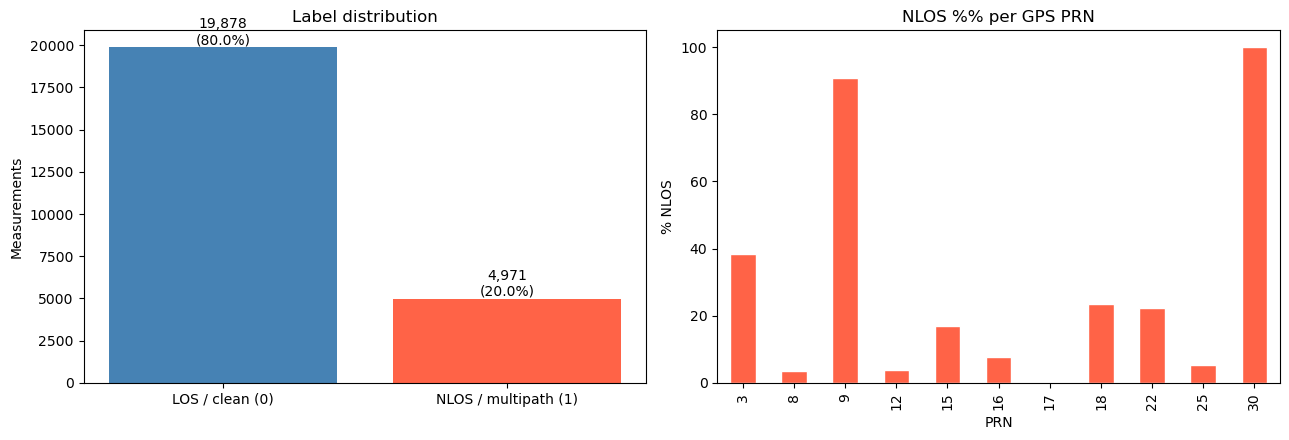

In [7]:
counts = df['multipath'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(['LOS / clean (0)', 'NLOS / multipath (1)'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', va='bottom')
axes[0].set_title('Label distribution'); axes[0].set_ylabel('Measurements')
pr = (df.groupby('PRN')['multipath'].mean()*100)
pr.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('NLOS %% per GPS PRN'); axes[1].set_ylabel('% NLOS'); axes[1].set_xlabel('PRN')
plt.tight_layout(); plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_27116\1429668421.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(g, labels=['LOS', 'NLOS'], patch_artist=True, boxprops=dict(facecolor='lightblue'),
C:\Users\Dell\AppData\Local\Temp\ipykernel_27116\1429668421.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(g, labels=['LOS', 'NLOS'], patch_artist=True, boxprops=dict(facecolor='lightblue'),
C:\Users\Dell\AppData\Local\Temp\ipykernel_27116\1429668421.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(g, labels=['LOS', 'NLOS'], patch_artist=True, boxprops=dict(facecolor='lightblue'),
C:\U

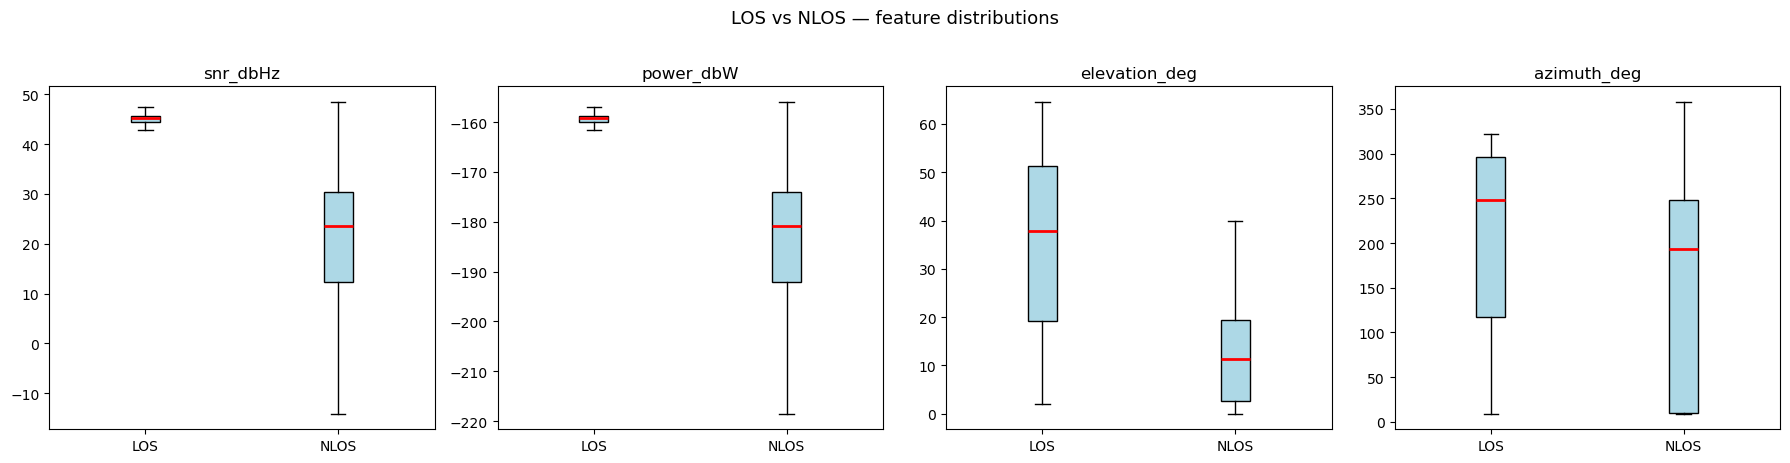

In [8]:
FEATS = ['snr_dbHz', 'power_dbW', 'elevation_deg', 'azimuth_deg']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, f in zip(axes, FEATS):
    g = [df.loc[df.multipath == v, f] for v in [0, 1]]
    ax.boxplot(g, labels=['LOS', 'NLOS'], patch_artist=True, boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2), showfliers=False)
    ax.set_title(f)
plt.suptitle('LOS vs NLOS — feature distributions', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

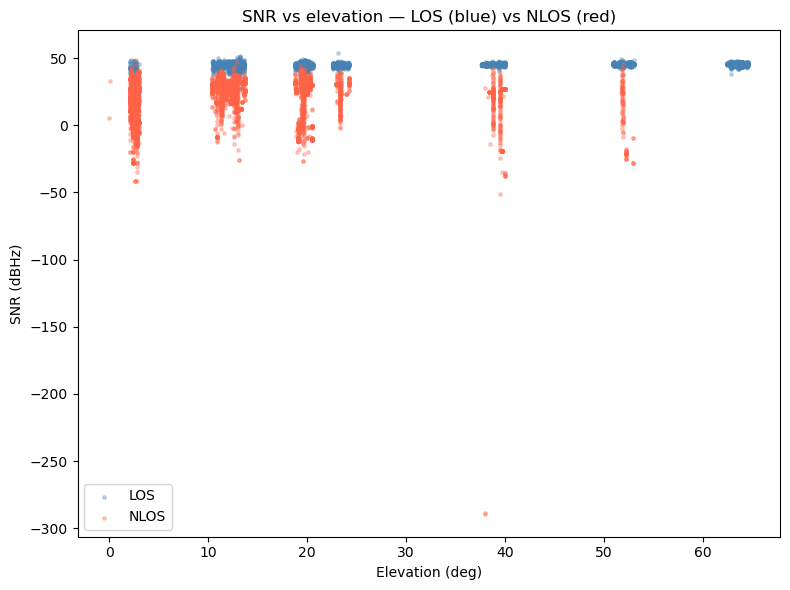

In [9]:
# SNR vs elevation, coloured by label — the core separation
fig, ax = plt.subplots(figsize=(8, 6))
for v, lbl, c in [(0, 'LOS', 'steelblue'), (1, 'NLOS', 'tomato')]:
    s = df[df.multipath == v].sample(min(6000, int((df.multipath == v).sum())), random_state=1)
    ax.scatter(s.elevation_deg, s.snr_dbHz, s=6, alpha=0.3, color=c, label=lbl)
ax.set_xlabel('Elevation (deg)'); ax.set_ylabel('SNR (dBHz)')
ax.set_title('SNR vs elevation — LOS (blue) vs NLOS (red)'); ax.legend()
plt.tight_layout(); plt.show()

### 3a. Skyplot — where multipath sits in the sky

Azimuth (0 deg = N, clockwise) and elevation (centre = overhead, outer ring = horizon). NLOS (red) should hug the horizon and cluster in the directions of the buildings that block/redirect the signals.

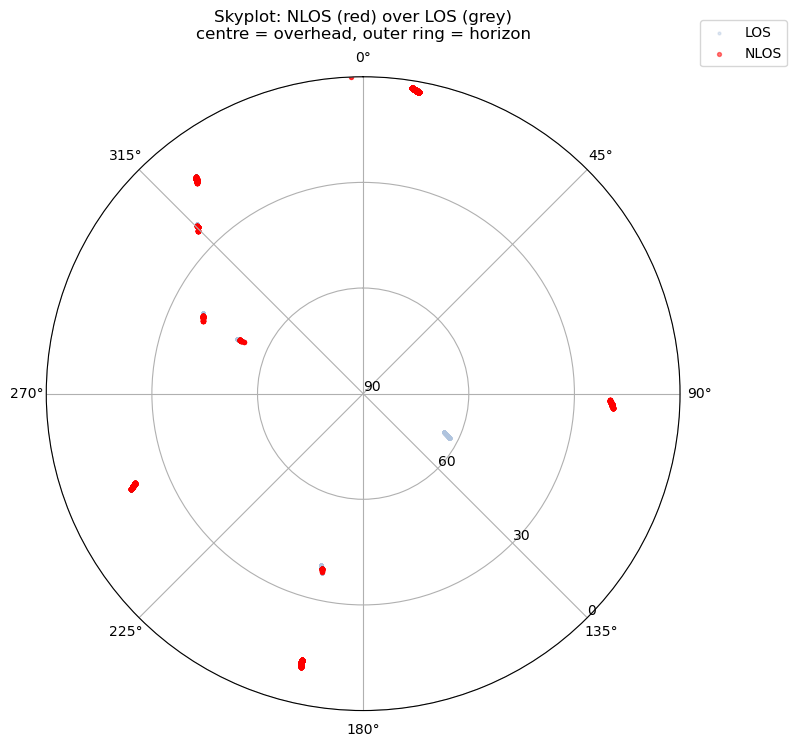

NLOS % by azimuth sector:
              n  nlos_pct
az_sector                
N-NE       2252      90.8
E-SE       5394       8.0
S-SW       4883      20.2
SW-W       2468      23.4
W-NW       6001       4.4
NW-N       3851      17.3


In [10]:
sky = df.dropna(subset=['azimuth_deg', 'elevation_deg'])
mp = sky[sky.multipath == 1]; cl = sky[sky.multipath == 0].sample(min(6000, int((sky.multipath==0).sum())), random_state=1)
fig = plt.figure(figsize=(8, 8)); ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
ax.scatter(np.radians(cl.azimuth_deg), 90 - cl.elevation_deg, s=4, c='lightsteelblue', alpha=0.4, label='LOS')
ax.scatter(np.radians(mp.azimuth_deg), 90 - mp.elevation_deg, s=8, c='red', alpha=0.5, label='NLOS')
ax.set_rmax(90); ax.set_rticks([0, 30, 60, 90]); ax.set_yticklabels(['90', '60', '30', '0']); ax.set_rlabel_position(135)
ax.set_title('Skyplot: NLOS (red) over LOS (grey)\ncentre = overhead, outer ring = horizon', va='bottom')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1.10)); plt.tight_layout(); plt.show()

sky = sky.copy()
sky['az_sector'] = pd.cut(sky.azimuth_deg, [0,45,90,135,180,225,270,315,360],
                          labels=['N-NE','NE-E','E-SE','SE-S','S-SW','SW-W','W-NW','NW-N'])
az = sky.groupby('az_sector', observed=True)['multipath'].agg(n='size', nlos_pct=lambda s: round(100*s.mean(),1))
print('NLOS % by azimuth sector:'); print(az.to_string())

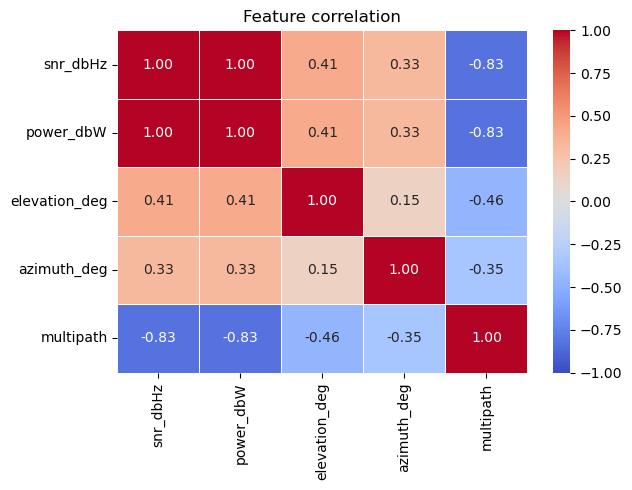

Correlation with multipath:
snr_dbHz        -0.827683
power_dbW       -0.827683
elevation_deg   -0.463567
azimuth_deg     -0.348929
Name: multipath, dtype: float64


In [11]:
corr = df[['snr_dbHz','power_dbW','elevation_deg','azimuth_deg','multipath']].corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature correlation'); plt.tight_layout(); plt.show()
print('Correlation with multipath:')
print(corr['multipath'].drop('multipath').sort_values(key=abs, ascending=False))

## 4. Feature Engineering

Signal-strength & elevation buckets, plus `sin`/`cos` of azimuth (so 0 deg and 360 deg are continuous). `epoch` is kept aside as a key for the temporal split and the map comparison.

In [12]:
df_ml = df.dropna(subset=['snr_dbHz', 'power_dbW', 'elevation_deg']).copy()
df_ml['az_sin'] = np.sin(np.radians(df_ml.azimuth_deg))
df_ml['az_cos'] = np.cos(np.radians(df_ml.azimuth_deg))
df_ml['SNR_cat'] = pd.cut(df_ml.snr_dbHz, [-np.inf, 25, 35, 45, np.inf], labels=['VeryLow','Low','Mid','High'])
df_ml['Elev_cat'] = pd.cut(df_ml.elevation_deg, [-1, 10, 20, 40, 91], labels=['VeryLow','Low','Mid','High'])
epoch_key = df_ml['epoch'].copy()
df_ml = pd.get_dummies(df_ml, columns=['SNR_cat', 'Elev_cat'])
df_ml = df_ml.drop(columns=['epoch', 'PRN', 'azimuth_deg'])
print('Feature columns:', [c for c in df_ml.columns if c != 'multipath'])
print('Shape:', df_ml.shape)
df_ml.head()

Feature columns: ['elevation_deg', 'snr_dbHz', 'power_dbW', 'az_sin', 'az_cos', 'SNR_cat_VeryLow', 'SNR_cat_Low', 'SNR_cat_Mid', 'SNR_cat_High', 'Elev_cat_VeryLow', 'Elev_cat_Low', 'Elev_cat_Mid', 'Elev_cat_High']
Shape: (24849, 14)


,elevation_deg,snr_dbHz,power_dbW,multipath,az_sin,az_cos,SNR_cat_VeryLow,SNR_cat_Low,SNR_cat_Mid,SNR_cat_High,Elev_cat_VeryLow,Elev_cat_Low,Elev_cat_Mid,Elev_cat_High
0,10.365150,47.403183,-157.004325,0,-0.223054,-0.974806,False,False,False,True,False,True,False,False
1,50.886043,44.726813,-159.680695,0,-0.917278,0.398247,False,False,True,False,False,False,False,True
2,2.984766,28.168592,-176.238917,1,0.183146,0.983086,False,True,False,False,True,False,False,False
3,39.831625,45.185010,-159.222499,0,-0.236750,-0.971571,False,False,False,True,False,False,True,False
4,18.845785,44.502209,-159.905299,0,0.998370,-0.057075,False,False,True,False,False,True,False,False


## 5. Multipath (NLOS) Classification — Optuna RF + threshold tuning

Same machinery as the SDC deep-dive: a **temporal split** (first 70% of the drive train, last 30% test — an unseen stretch of road), **Optuna** hyperparameter search with **SMOTE inside CV**, decision-threshold tuning on out-of-fold probabilities, and a **Logistic-Regression linear baseline**. There is **no coordinate feature** — the model sees only signal + geometry, so it cannot memorise location.

In [13]:
import optuna
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_curve, auc, roc_auc_score)
optuna.logging.set_verbosity(optuna.logging.WARNING)

order = np.argsort(epoch_key.values, kind='stable')
df_ord = df_ml.iloc[order].reset_index(drop=True)
key_ord = epoch_key.iloc[order].reset_index(drop=True)
split_t = key_ord.iloc[int(0.70 * len(df_ord))]
is_test = (key_ord > split_t).values

X = df_ord.drop(columns=['multipath']); y = df_ord['multipath'].astype(int)
X_train, X_test = X[~is_test].copy(), X[is_test].copy()
y_train = y[~is_test].reset_index(drop=True); y_test = y[is_test].reset_index(drop=True)
key_test = key_ord[is_test].reset_index(drop=True)
med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med).reset_index(drop=True); X_test = X_test.fillna(med).reset_index(drop=True)
print(f'Train: {X_train.shape} ({y_train.mean()*100:.1f}% NLOS)  |  Test: {X_test.shape} ({y_test.mean()*100:.1f}% NLOS)')

Train: (17400, 13) (20.5% NLOS)  |  Test: (7449, 13) (18.9% NLOS)


### 5a. Optuna hyperparameter search (SMOTE inside CV)

In [14]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
def make_pipe(params):
    return ImbPipeline([('smote', SMOTE(random_state=42)),
                        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, **params))])
def objective(trial):
    params = dict(n_estimators=trial.suggest_int('n_estimators', 150, 400, step=50),
                  max_depth=trial.suggest_int('max_depth', 5, 25),
                  min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 8),
                  max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]))
    return cross_val_score(make_pipe(params), X_train, y_train, cv=cv, scoring='f1', n_jobs=1).mean()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=25, timeout=600, show_progress_bar=False)
print(f'Best CV F1: {study.best_value:.4f}'); print('Best params:', study.best_params)

Best CV F1: 0.9852
Best params: {'n_estimators': 400, 'max_depth': 13, 'min_samples_leaf': 2, 'max_features': 0.5}


### 5b. Refit, threshold tuning, and evaluation

In [15]:
best_pipe = make_pipe(study.best_params).fit(X_train, y_train)
y_prob = best_pipe.predict_proba(X_test)[:, 1]
base_pipe = make_pipe(dict(n_estimators=200)).fit(X_train, y_train)
base_prob = base_pipe.predict_proba(X_test)[:, 1]

# threshold tuning on out-of-fold train probabilities
oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
ths = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_train, (oof >= t).astype(int)) for t in ths]
best_t = float(ths[int(np.argmax(f1s))])
y_pred_default = (y_prob >= 0.5).astype(int); y_pred_tuned = (y_prob >= best_t).astype(int)
print(f'Tuned threshold: {best_t:.3f}\n')
print('=== Optuna-tuned RF @ tuned threshold ===')
print(classification_report(y_test, y_pred_tuned, target_names=['LOS', 'NLOS']))

# linear baseline
lr = ImbPipeline([('sc', StandardScaler()), ('smote', SMOTE(random_state=42)),
                  ('lr', LogisticRegression(max_iter=1000, random_state=42))]).fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]; lr_pred = (lr_prob >= 0.5).astype(int)

board = pd.DataFrame({
  'precision': [0.0, precision_score(y_test, lr_pred, zero_division=0), precision_score(y_test, y_pred_tuned, zero_division=0)],
  'recall':    [0.0, recall_score(y_test, lr_pred), recall_score(y_test, y_pred_tuned)],
  'f1':        [0.0, f1_score(y_test, lr_pred), f1_score(y_test, y_pred_tuned)],
  'roc_auc':   [0.5, roc_auc_score(y_test, lr_prob), roc_auc_score(y_test, y_prob)],
}, index=['Majority-class (all LOS)', 'Logistic Regression (linear)', 'Random Forest (Optuna+thr)']).round(4)
print('\nNLOS-class leaderboard (temporal test set):'); print(board.to_string())
y_pred = y_pred_tuned

Tuned threshold: 0.715

=== Optuna-tuned RF @ tuned threshold ===
              precision    recall  f1-score   support

         LOS       1.00      1.00      1.00      6043
        NLOS       0.99      0.99      0.99      1406

    accuracy                           1.00      7449
   macro avg       0.99      0.99      0.99      7449
weighted avg       1.00      1.00      1.00      7449


NLOS-class leaderboard (temporal test set):
                              precision  recall      f1  roc_auc
Majority-class (all LOS)         0.0000  0.0000  0.0000   0.5000
Logistic Regression (linear)     0.9804  0.9957  0.9880   0.9997
Random Forest (Optuna+thr)       0.9858  0.9908  0.9883   0.9991


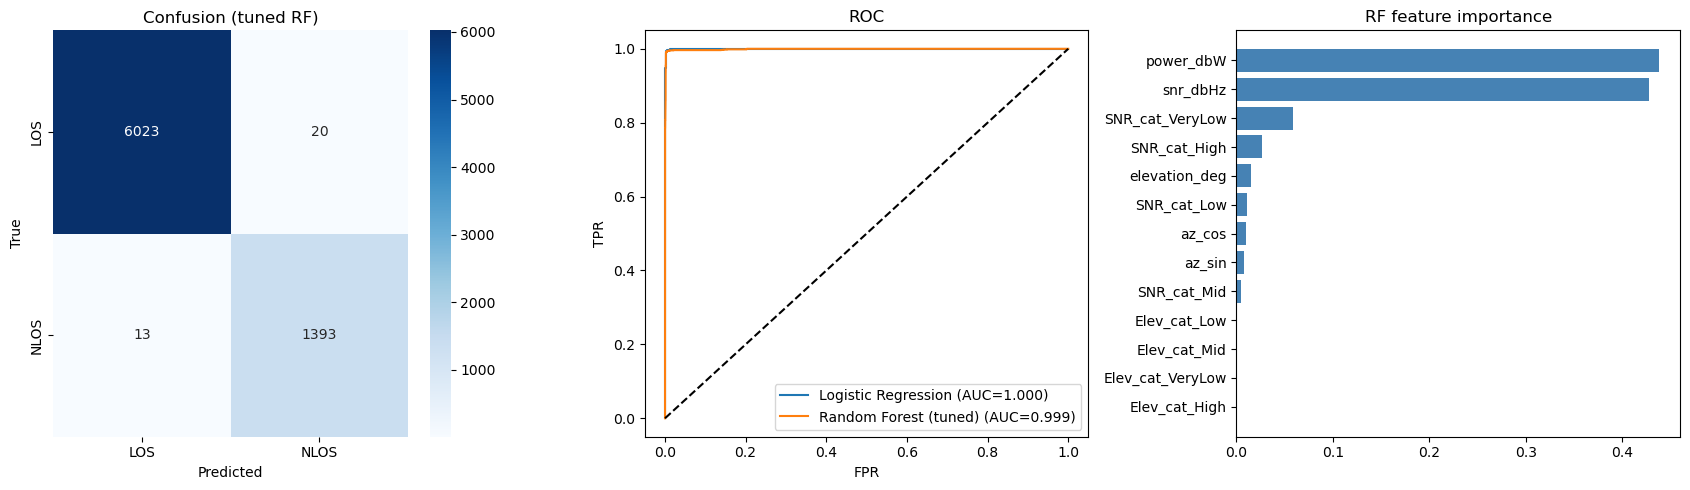

         Feature  Importance
       power_dbW    0.437910
        snr_dbHz    0.427175
 SNR_cat_VeryLow    0.058486
    SNR_cat_High    0.026763
   elevation_deg    0.015331
     SNR_cat_Low    0.011076
          az_cos    0.009943
          az_sin    0.007492
     SNR_cat_Mid    0.004992
    Elev_cat_Low    0.000440
    Elev_cat_Mid    0.000156
Elev_cat_VeryLow    0.000134
   Elev_cat_High    0.000101


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['LOS','NLOS'], yticklabels=['LOS','NLOS'])
axes[0].set_title('Confusion (tuned RF)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
for name, prob in [('Logistic Regression', lr_prob), ('Random Forest (tuned)', y_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob); axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title('ROC'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(loc='lower right')
imp = pd.DataFrame({'Feature': X.columns, 'Importance': best_pipe.named_steps['rf'].feature_importances_}).sort_values('Importance')
axes[2].barh(imp.Feature, imp.Importance, color='steelblue'); axes[2].set_title('RF feature importance')
plt.tight_layout(); plt.show()
print(imp.sort_values('Importance', ascending=False).to_string(index=False))

### SHAP interpretation — Warwick SE-NAV RF (own full feature set)

`TreeExplainer` decomposes each prediction into per-feature contributions on the model's **own** full feature set. The beeswarm shows the direction of each feature's effect; the bar chart ranks mean |SHAP|; the dependence plots show the shape of the top features' effects. SHAP explains the fitted Random Forest evaluated on the held-out **test** measurements.

SHAP values: (2000, 13)


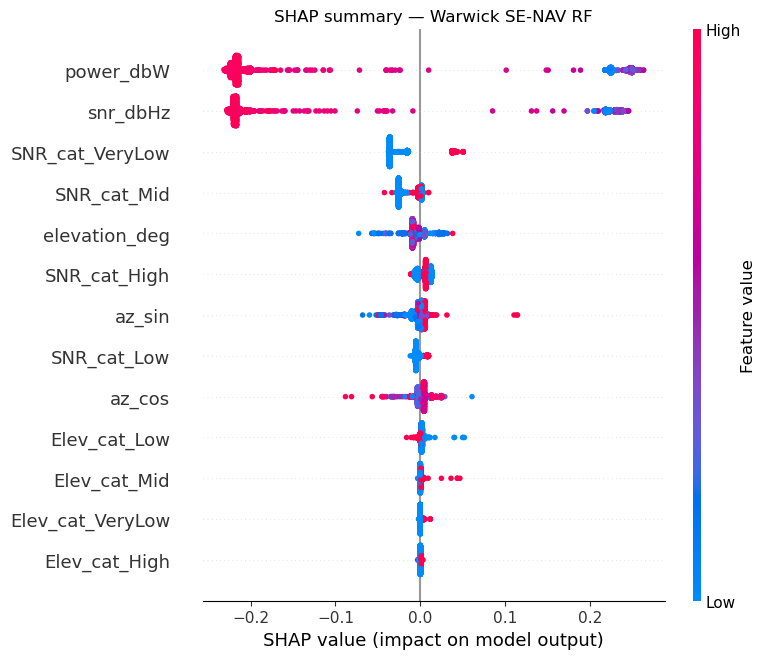

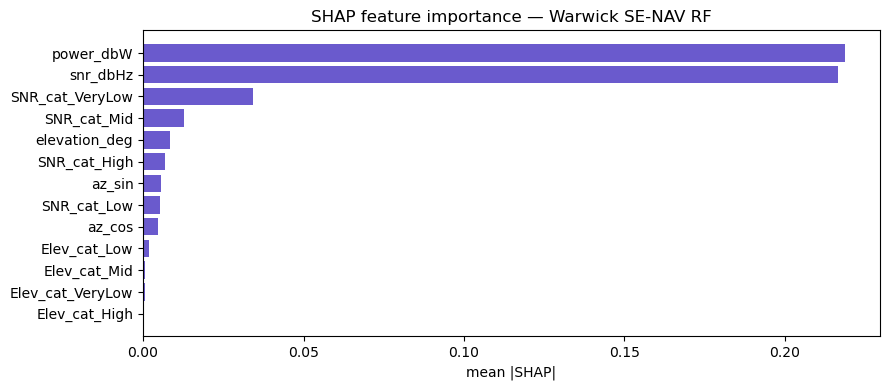

power_dbW          0.2187
snr_dbHz           0.2166
SNR_cat_VeryLow    0.0342
SNR_cat_Mid        0.0126
elevation_deg      0.0083
SNR_cat_High       0.0068
az_sin             0.0054
SNR_cat_Low        0.0053


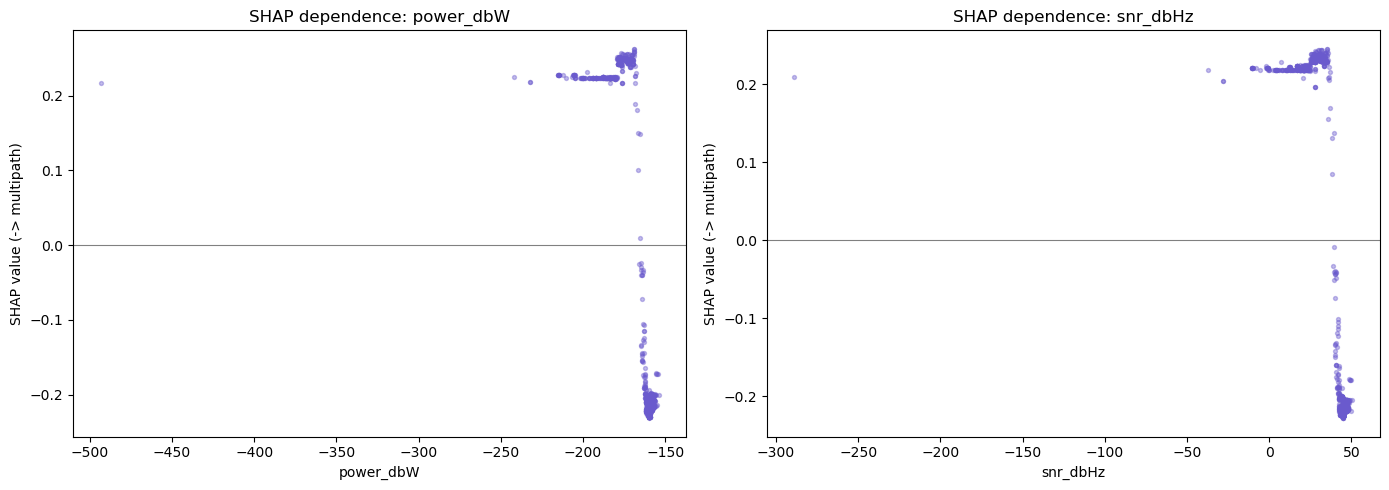

In [17]:
import shap
rf_shap = best_pipe.named_steps['rf']
X_shap = X_test.sample(min(2000, len(X_test)), random_state=0)
sv = np.asarray(shap.TreeExplainer(rf_shap).shap_values(X_shap))
if sv.ndim == 3: sv = sv[:, :, 1]            # positive (multipath/NLOS) class
print('SHAP values:', sv.shape)

# (a) beeswarm summary
shap.summary_plot(sv, X_shap, show=False)
plt.title('SHAP summary — Warwick SE-NAV RF'); plt.tight_layout(); plt.show()

# (b) mean|SHAP| importance
mshap = pd.Series(np.abs(sv).mean(0), index=list(X.columns)).sort_values()
plt.figure(figsize=(9, max(4, len(mshap)*0.3)))
plt.barh(mshap.index, mshap.values, color='slateblue')
plt.xlabel('mean |SHAP|'); plt.title('SHAP feature importance — Warwick SE-NAV RF')
plt.tight_layout(); plt.show()
print(mshap.sort_values(ascending=False).head(8).round(4).to_string())

# (c) dependence for the two strongest features
top2 = mshap.sort_values(ascending=False).index[:2]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(np.atleast_1d(axes), top2):
    j = list(X.columns).index(feat)
    ax.scatter(X_shap[feat], sv[:, j], s=8, alpha=0.4, color='slateblue')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xlabel(feat); ax.set_ylabel('SHAP value (-> multipath)')
    ax.set_title(f'SHAP dependence: {feat}')
plt.tight_layout(); plt.show()

## 6. Actual vs Predicted Multipath — on the Map

The held-out test segment (last 30% of the drive), aggregated per epoch: actual vs predicted NLOS fraction at each vehicle location.

Test epochs: 968   per-epoch NLOS-fraction MAE=0.005  Pearson r=0.986
Epoch-level 'any NLOS?' agreement: 99.0%


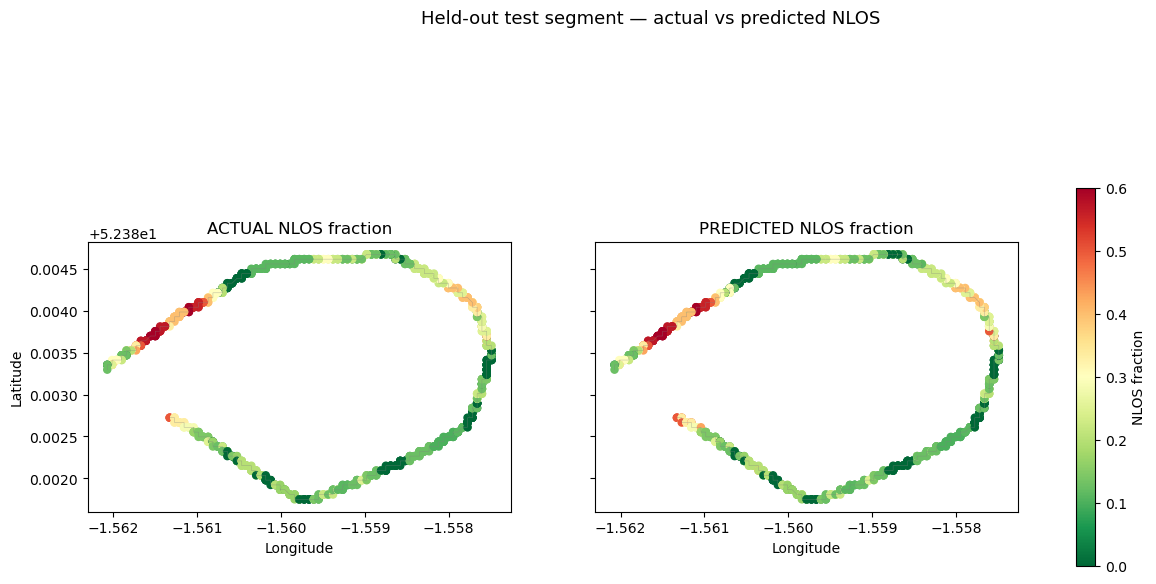

In [18]:
cmpdf = pd.DataFrame({'epoch': key_test.values, 'actual': y_test.values, 'pred': y_pred})
per = cmpdf.groupby('epoch').agg(n=('actual','size'), actual_mp=('actual','sum'), pred_mp=('pred','sum')).reset_index()
per['actual_frac'] = per.actual_mp / per.n; per['pred_frac'] = per.pred_mp / per.n
per = per.merge(veh_df, on='epoch', how='left').dropna(subset=['lat', 'lon'])
mae = (per.actual_frac - per.pred_frac).abs().mean(); r = per.actual_frac.corr(per.pred_frac)
agree = ((per.actual_mp > 0).astype(int) == (per.pred_mp > 0).astype(int)).mean()
print(f'Test epochs: {len(per):,}   per-epoch NLOS-fraction MAE={mae:.3f}  Pearson r={r:.3f}')
print(f"Epoch-level 'any NLOS?' agreement: {agree*100:.1f}%")

vmax = per.actual_frac.quantile(0.98)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for ax, col, title in [(axes[0], 'actual_frac', 'ACTUAL NLOS fraction'), (axes[1], 'pred_frac', 'PREDICTED NLOS fraction')]:
    sc = ax.scatter(per.lon, per.lat, c=per[col], cmap='RdYlGn_r', s=26, vmin=0, vmax=vmax)
    ax.plot(per.lon, per.lat, color='gray', lw=0.4, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('Longitude'); ax.set_aspect('equal', adjustable='box')
axes[0].set_ylabel('Latitude'); fig.colorbar(sc, ax=axes, label='NLOS fraction', shrink=0.7)
plt.suptitle('Held-out test segment — actual vs predicted NLOS', y=1.02, fontsize=13); plt.show()

### 6a. Spot-check a coordinate

Snap any lat/lon to the nearest point on the route and ask the model whether it is multipath there.

In [19]:
QUERY = (52.3820, -1.5610)   # edit me (decimal degrees)
qlat, qlon = QUERY
e = epoch_map.copy()
e['d_m'] = np.sqrt(((e.lat-qlat)*111320)**2 + ((e.lon-qlon)*111320*np.cos(np.radians(qlat)))**2)
hit = e.loc[e.d_m.idxmin()]; t_epoch = int(hit.epoch)
print(f'Query {qlat:.5f}, {qlon:.5f}  ->  nearest route point {hit.lat:.5f}, {hit.lon:.5f} ({hit.d_m:.1f} m)')
mask = (key_ord.values == t_epoch); n_here = int(mask.sum())
if n_here:
    Xh = X[mask].fillna(med); yh = y.to_numpy()[mask]
    ph = best_pipe.predict_proba(Xh)[:, 1]; predh = (ph >= best_t).astype(int)
    seg = 'HELD-OUT TEST' if bool(is_test[mask][0]) else 'TRAINING'
    print(f'Visible sats: {n_here}  |  segment: {seg}')
    print(f'ACTUAL   NLOS: {int(yh.sum())}/{n_here}   PREDICTED NLOS: {int(predh.sum())}/{n_here}')
    print(f"\n>>> MODEL VERDICT: {'MULTIPATH' if predh.sum()>0 else 'CLEAN'} (actual: {'MULTIPATH' if yh.sum()>0 else 'CLEAN'})")

Query 52.38200, -1.56100  ->  nearest route point 52.38227, -1.56064 (38.4 m)
Visible sats: 6  |  segment: HELD-OUT TEST
ACTUAL   NLOS: 0/6   PREDICTED NLOS: 0/6

>>> MODEL VERDICT: CLEAN (actual: CLEAN)


## 7. Takeaways

- The SE-NAV ray-tracer gives **exact NLOS ground truth**, so the classes separate cleanly: NLOS satellites are low-elevation and ~20 dB weaker in SNR than LOS.
- A temporal-split Random Forest (Optuna-tuned, threshold-tuned) recovers this almost perfectly, and comfortably beats the linear Logistic-Regression baseline — but note the task is *easier* than the real-device SDC data because the simulated labels are noise-free.
- With **no coordinate feature** and a temporal (unseen-road) test split, the model is detecting multipath from **signal + geometry** (SNR, power, elevation dominate the importances), not from memorised location.
- The skyplot and azimuth-sector table show NLOS is both **low-elevation** and **direction-specific** — the signature of the surrounding buildings in the SE-NAV city model.
- Because the labels come from physics (not a device flag), this simulation is a clean **upper-bound / sanity-check** companion to the real-device SDC-2023 pipeline.